In [7]:
import matplotlib.pyplot as plt
import networkx as nx

from graph_loader import build_graph
from metrics import calculate_metrics
from community_detection import run_community_detection

In [8]:
def get_layout(G, layout_type="spring"):
    if layout_type == "spring":
        return nx.spring_layout(G, seed=42)

    elif layout_type == "circular":
        return nx.circular_layout(G)

    elif layout_type == "shell":
        return nx.shell_layout(G)

    elif layout_type == "hierarchical":
        try:
            from networkx.drawing.nx_agraph import graphviz_layout
            return graphviz_layout(G, prog="dot")
        except:
            print("Graphviz not installed → fallback to spring layout")
            return nx.spring_layout(G, seed=42)

    return nx.spring_layout(G, seed=42)

In [9]:
def draw_basic_graph(G, layout_type="spring"):
    pos = get_layout(G, layout_type)

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color="lightblue",
        edge_color="gray",
        node_size=800,
        font_size=10
    )

    plt.title(f"Basic Graph ({layout_type})")
    plt.show()


In [ ]:
def draw_graph_with_metrics(G, layout_type="spring"):
    pos = get_layout(G, layout_type)

    metrics, _ = calculate_metrics(G)

    pagerank_values = [metrics[n]["Pagerank"] for n in G.nodes()]
    min_pr = min(pagerank_values)
    max_pr = max(pagerank_values)

    node_colors = [
        (metrics[n]["Pagerank"] - min_pr) / (max_pr - min_pr + 1e-9)
        for n in G.nodes()
    ]

    node_sizes = [300 + metrics[n]["Degree"] * 2000 for n in G.nodes()]

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=node_sizes,
        node_color=node_colors,
        cmap=plt.cm.Reds,
        edge_color="gray"
    )

    plt.title(f"Graph with Metrics ({layout_type})")

    sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds)
    sm.set_array([])

    plt.colorbar(sm, ax=plt.gca(), label="PageRank (Normalized)")

    plt.show()

In [11]:
def draw_communities(G, layout_type="spring"):
    pos = get_layout(G, layout_type)

    results = run_community_detection(G)
    partition = results["louvain"]["mapping"]

    node_colors = [partition[n] for n in G.nodes()]

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=node_colors,
        cmap=plt.cm.tab10,
        node_size=900,
        edge_color="gray"
    )

    plt.title("Communities (Louvain)")
    plt.show()

In [12]:
def draw_advanced(G, layout_type="spring"):
    pos = get_layout(G, layout_type)

    metrics, _ = calculate_metrics(G)
    results = run_community_detection(G)
    partition = results["louvain"]["mapping"]

    node_sizes = [300 + metrics[n]["Degree"] * 2000 for n in G.nodes()]
    node_colors = [partition[n] for n in G.nodes()]

    edge_widths = [G[u][v].get("weight", 1) for u, v in G.edges()]

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=node_sizes,
        node_color=node_colors,
        cmap=plt.cm.tab10,
        edge_color="gray",
        width=edge_widths,
        font_size=10
    )

    plt.title("Advanced Graph (Metrics + Communities + Weights)")
    plt.show()

In [22]:
if __name__ == "__main__":
    
    G = build_graph("data/nodes.csv", "data/edges.csv", directed=True)



===== Choose Graph Layout =====
1. Spring (Force Directed)
2. Circular
3. Hierarchical


✅ You selected: circular


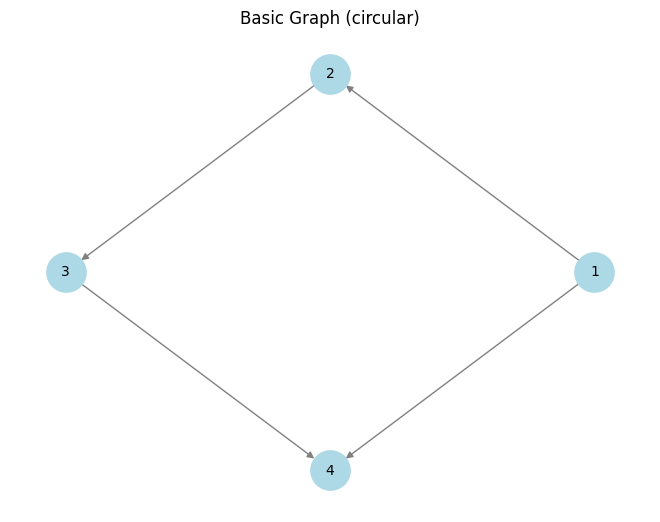

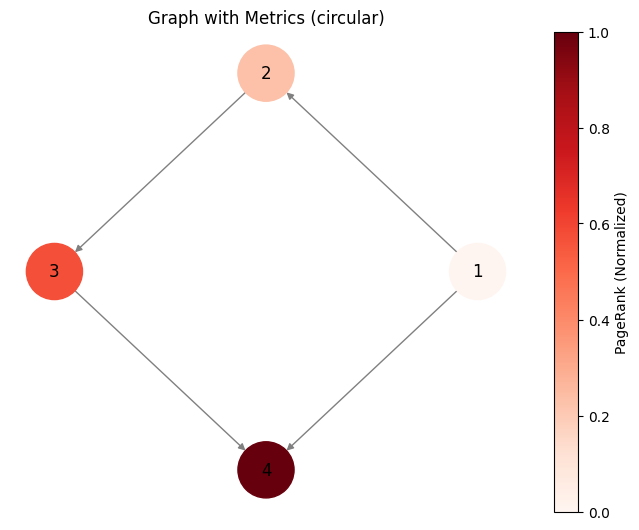

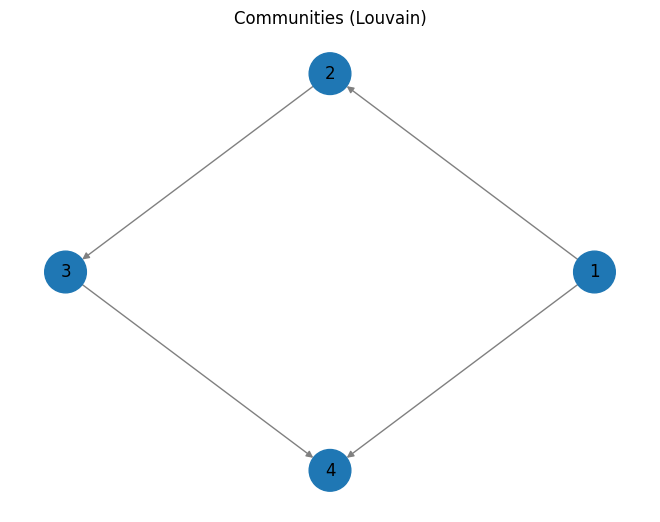

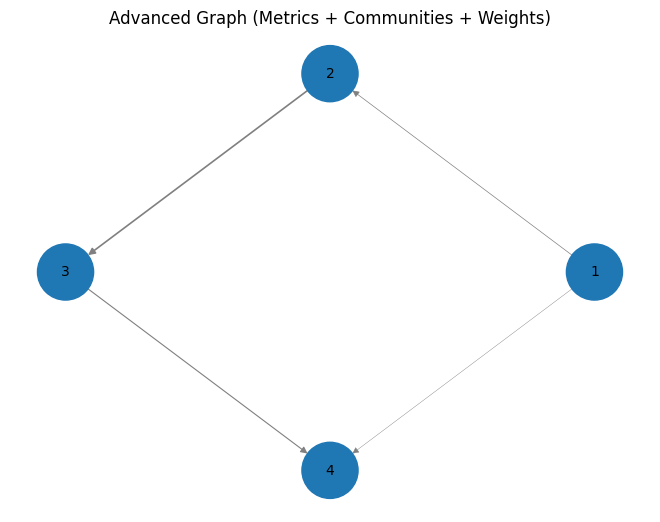

In [25]:
print("""
===== Choose Graph Layout =====
1. Spring (Force Directed)
2. Circular
3. Hierarchical
==============================
""")

choice = input("Enter your choice (1/2/3): ")

layouts = {
    "1": "spring",
    "2": "circular",
    "3": "hierarchical"
}

layout = layouts.get(choice, "spring")

print(f"\n✅ You selected: {layout}")
draw_basic_graph(G, layout)
draw_graph_with_metrics(G, layout)
draw_communities(G, layout)
draw_advanced(G, layout)